In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/train_scaled.csv")

max_cycle = df.groupby("engine_id")["cycle"].transform("max")

df["life_ratio"] = df["cycle"] / max_cycle

sensor_cols = [c for c in df.columns if "sensor" in c]

## added life_ratio to give temporal context to the data point
features = sensor_cols + ["cycle", "life_ratio"]

X = df[features]
y = df["RUL"]

In [10]:
# train / test split using engine id to avoid data leakage...
from sklearn.model_selection import train_test_split

engine_ids = df.engine_id.unique()

train_ids, test_ids = train_test_split(engine_ids, test_size=0.2, random_state=42)

train_df = df[df.engine_id.isin(train_ids)]
test_df = df[df.engine_id.isin(test_ids)]

X_train = train_df[sensor_cols]
y_train = train_df["RUL"]

X_test = test_df[sensor_cols]
y_test = test_df["RUL"]

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 16.47991019924159
Linear Regression RMSE: 20.40611783821649


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf_baseline = mean_absolute_error(y_test, pred_rf)
rmse_rf_baseline = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf_baseline)
print("Random Forest RMSE:", rmse_rf_baseline)

Random Forest MAE: 12.427320560208047
Random Forest RMSE: 17.02335221728995


In [21]:
print("Model Comparison")
print("----------------")
print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf_baseline)

Model Comparison
----------------
Linear Regression RMSE: 20.40611783821649
Random Forest RMSE: 17.02335221728995


In [ ]:
# BASELINE Model Comparison 
# ----------------
# Linear Regression RMSE: 20.40611783821649
# Random Forest RMSE: 17.02335221728995

# linear regression on average predicts off by ~ 20 cycle
# random forest on average predicts off by ~ 17 cycle
# since we had made sure RUL - [0,125] so its kinda reasonable


# 1 fact to note - since linear regression asssumes linear relationship but degradation is obviously non-linear, so random forest should have performed better (its doing so but still the difference should have been a bit more ig)

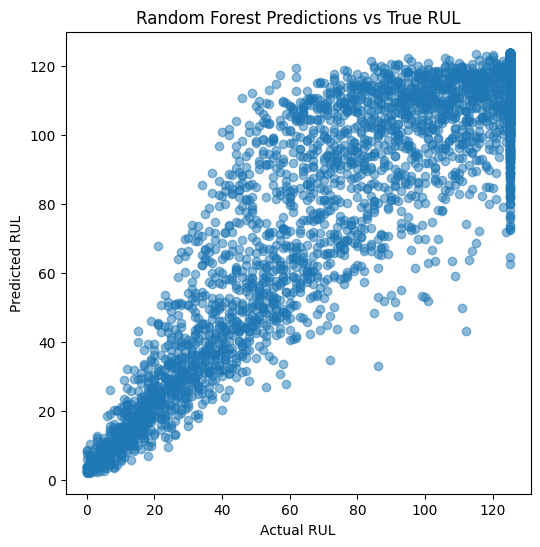

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest Predictions vs True RUL")
plt.show()

In [ ]:
# Adding cycle based degradation features did not significantly improve performance, maybe because the sensor measurements already implicitly encoded the engine’s degradation state.

In [ ]:
# tuning the hyper-parameters of random forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Fitting 3 folds for each of 24 candidates, totalling 72 fits
# Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}



Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}


In [24]:
# training with best parameters
best_rf = RandomForestRegressor(
    **grid.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Tuned Random Forest RMSE:", rmse_rf)

Tuned Random Forest RMSE: 17.006485571786786


In [26]:
print("Linear Regression RMSE:", rmse_lr)
print("Baseline RF RMSE:", rmse_rf_baseline)
print("Tuned RF RMSE:", rmse_rf)

Linear Regression RMSE: 20.40611783821649
Baseline RF RMSE: 17.02335221728995
Tuned RF RMSE: 17.006485571786786


In [ ]:
# Linear Regression RMSE: 20.40611783821649
# Baseline RF RMSE: 17.02335221728995
# Tuned RF RMSE: 17.006485571786786

# tuning the RF didn't help maybe because - RF is already at its capacity on this feature representation